# 01 · Climate, STAC, and Copernicus C3S

**Decision question.** How do we discover relevant Earth observations and distinguish a climate signal from a synthetic health association?

**Time:** 30–45 minutes. **Prerequisites:** basic Python arrays and tables. Run cells from top to bottom.
The shared `rewiring.py` module must stay beside the notebooks. Initial package downloads require internet;
the core calculations use reproducible synthetic data. No health-service credentials are needed.

**Data contract:** the fictional grid is geographically anchored near Gaborone for teaching map coordinates.
Its people, facilities, climate, events, and model parameters are invented. It is **not a map of actual
Gaborone disease, vulnerability, buildings, or care access**. Satellite catalog metadata, when used, is labeled separately.

[Book](https://jltobias.github.io/JupyterLite-Rewiring-Global-Health/) · [Interactive demo gallery](https://jltobias.github.io/JupyterLite-Rewiring-Global-Health/demos/) · [Data and credits](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/DATA_SOURCES.md)

In [1]:
import sys
if sys.platform == 'emscripten':
    import micropip
    await micropip.install(['numpy', 'pandas', 'matplotlib'])
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, IFrame
from rewiring import (city, long_table, map_image, map_matrix, geojson,
                      leaflet, save_export, simulate_twin, teaching_review, HATS, SITE, LABEL, EXTENT)
plt.rcParams.update({'figure.dpi': 105, 'axes.spines.top': False, 'axes.spines.right': False})
cells, cube = city()
panel = long_table(cells, cube)
print(LABEL)
print('Python', sys.version.split()[0], '| cells:', len(cells), '| monthly observations:', len(panel))

SYNTHETIC teaching data · not observations or a forecast
Python 3.13.14 | cells: 64 | monthly observations: 1536


## Discovery is not evidence of a health effect

STAC describes where and when assets exist. C3S provides climate products and the Interactive Climate Atlas
provides exploration of climate information. A Sentinel-2 image is not a C3S temperature projection.
We inspect real satellite metadata, then use a separately labeled synthetic cube to practice calculations.

![Discovery to interpretation](assets/data-journey.svg)

In [2]:
snapshot = json.loads(Path('data/stac-snapshot.json').read_text())
catalog = pd.DataFrame([{'id':f['id'], 'datetime':f['properties']['datetime'],
                        'cloud_percent':f['properties'].get('eo:cloud_cover'),
                        'assets':len(f['assets'])} for f in snapshot['items']])
print('OBSERVED SATELLITE CATALOG METADATA | retrieved',snapshot['retrieved'])
display(catalog)

OBSERVED SATELLITE CATALOG METADATA | retrieved 2026-10-04


,id,datetime,cloud_percent,assets
0,S2C_35JLN_20250123_0_L2A,2025-01-23T08:27:41.731000Z,6.982274,38
1,S2C_35JMN_20250123_0_L2A,2025-01-23T08:27:38.405000Z,13.851388,38
2,S2B_35JLN_20250118_0_L2A,2025-01-18T08:27:12.413000Z,99.939018,35


## Optional live metadata request

The bundled snapshot makes the lesson repeatable. Set `LIVE_STAC=True` to request up to three items from
Element 84 Earth Search. No raster is downloaded. Catalog availability and browser CORS rules can change;
a failed request leaves the snapshot available. The query covers January 2025, not current conditions.

In [3]:
LIVE_STAC = False
if LIVE_STAC:
    try:
        if sys.platform == 'emscripten':
            from pyodide.http import pyfetch
            response = await pyfetch(snapshot['source_url'])
            if response.status != 200: raise RuntimeError(f'HTTP {response.status}')
            live = await response.json()
        else:
            import urllib.request
            with urllib.request.urlopen(snapshot['source_url'], timeout=20) as response:
                live = json.load(response)
        print('Live item IDs:', [f['id'] for f in live['features']])
    except Exception as exc:
        print('Live metadata unavailable; bundled snapshot still usable:', type(exc).__name__)
else:
    print('Using the bundled satellite metadata snapshot; no external request made.')

Using the bundled satellite metadata snapshot; no external request made.


## Inspect an asset contract

Before loading a band, inspect its media type, scale/offset, CRS, resolution, missing values, and license.
Cloud percentage for a whole scene is not the cloud fraction over your study area. Satellite reflectance
cannot be relabeled as temperature or disease incidence.

In [4]:
item = snapshot['items'][0]
asset = item['assets']['red']
display(pd.Series({k:asset.get(k) for k in ['href','type','roles','raster:bands','eo:bands','proj:shape']}))
print('License links:', [link['href'] for link in item['links'] if link['rel']=='license'])

href            https://sentinel-cogs.s3.us-west-2.amazonaws.c...
type            image/tiff; application=geotiff; profile=cloud...
roles                                         [data, reflectance]
raster:bands    [{'nodata': 0, 'data_type': 'uint16', 'spatial...
eo:bands        [{'name': 'B04', 'common_name': 'red', 'center...
proj:shape                                         [10980, 10980]
dtype: object

License links: ['https://sentinel.esa.int/documents/247904/690755/Sentinel_Data_Legal_Notice']


## Synthetic anomalies and spatial comparison

An anomaly needs a reference period. Here it is each cell's first twelve invented monthly temperatures,
not a climatological 30-year normal. Compare two seasons with the same temperature scale, and use a
diverging scale centered on zero for departures from that reference.

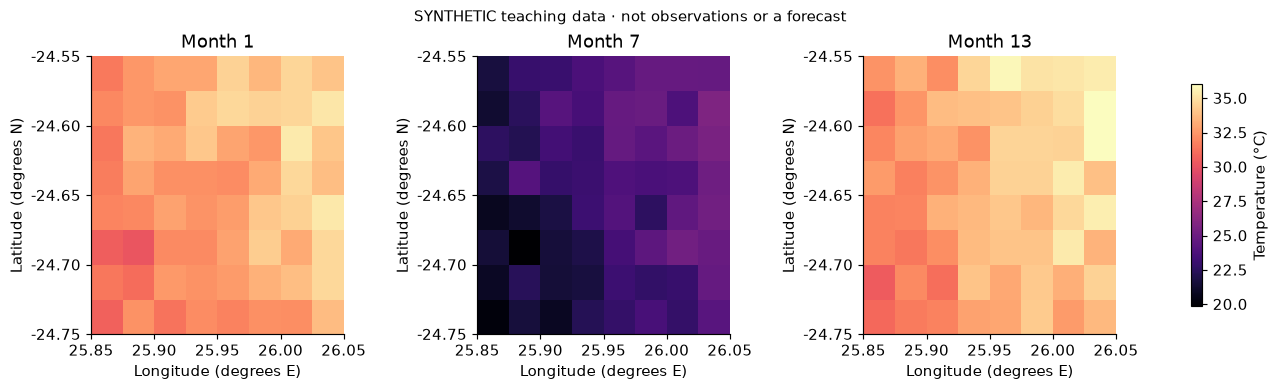

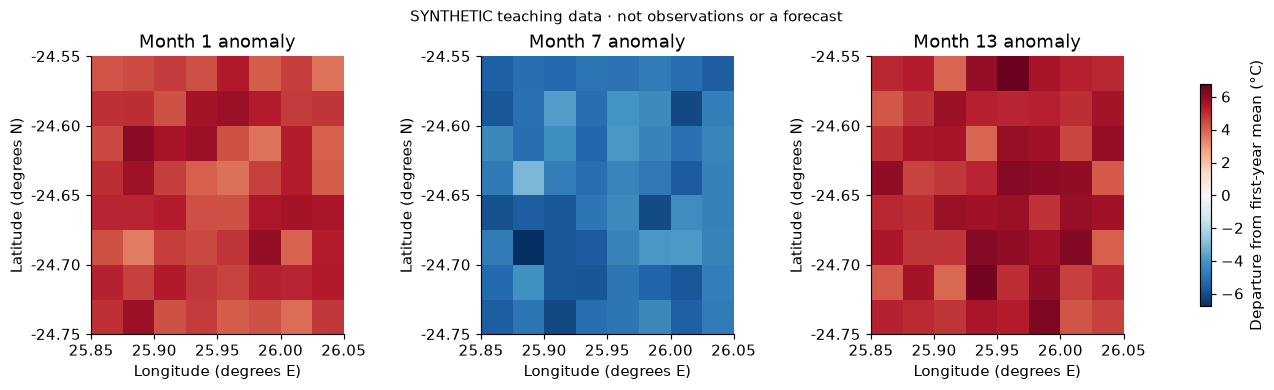

In [5]:
heat = cube['heat_c']
reference = heat[:12].mean(axis=0)
anomaly = heat - reference
map_matrix(heat[[0,6,12]], ['Month 1','Month 7','Month 13'], 'Temperature (°C)', cmap='magma')
plt.show()
limit = float(np.abs(anomaly).max())
map_matrix(anomaly[[0,6,12]], ['Month 1 anomaly','Month 7 anomaly','Month 13 anomaly'],
           'Departure from first-year mean (°C)', cmap='RdBu_r', limits=(-limit,limit))
plt.show()

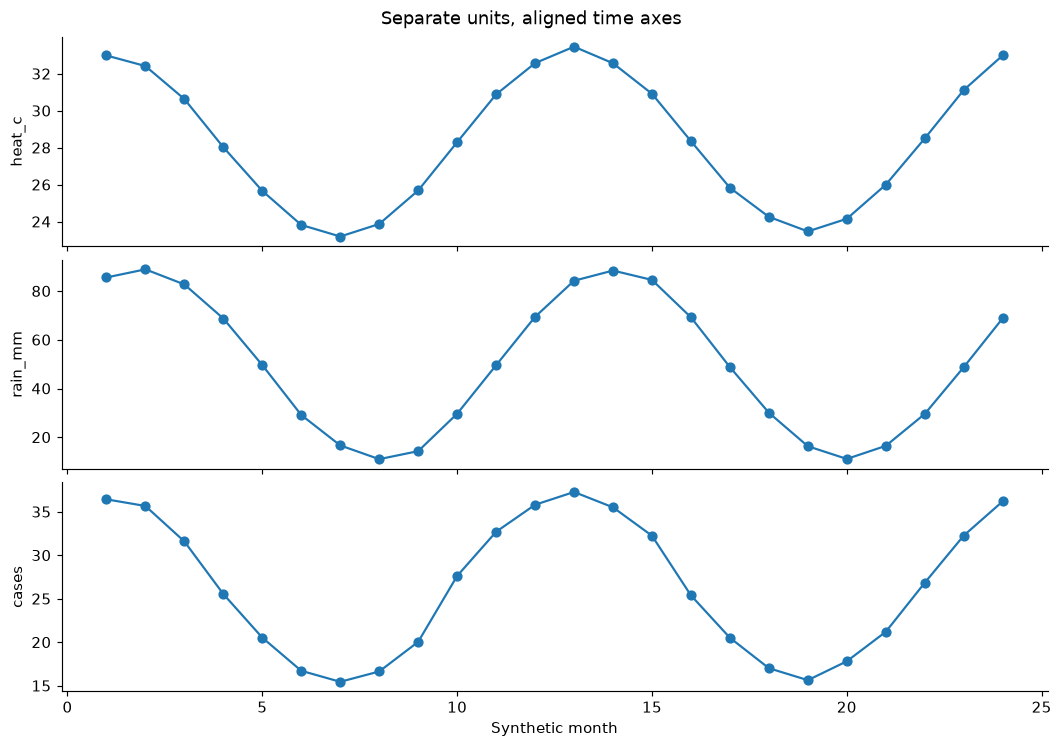

In [6]:
monthly = panel.groupby('month')[['heat_c','rain_mm','cases']].mean()
fig, axes = plt.subplots(3,1,figsize=(10,7),sharex=True,layout='constrained')
for ax,name in zip(axes,monthly):
    ax.plot(monthly.index+1,monthly[name],marker='o'); ax.set_ylabel(name)
axes[-1].set_xlabel('Synthetic month'); fig.suptitle('Separate units, aligned time axes'); plt.show()

## A C3S Atlas exercise with a reproducible record

Open the [Copernicus Interactive Climate Atlas](https://atlas.climate.copernicus.eu/).
Choose a region, temperature indicator, reference period, scenario/warming level, and future period.
Compare model spread as well as the ensemble mean. Export the provenance supplied by the product.
Use the [Climate Data Store](https://cds.climate.copernicus.eu/) for product-specific access and terms.
The notebook does not imply that CDS account credentials belong in public browser code.

In [7]:
provenance = pd.DataFrame({'field':['product and version','producer','reference period','future period',
 'scenario / warming level','units','grid / CRS','ensemble statistic','license and DOI','retrieval date'],
 'record':['REQUIRED: fill from selected product']*10})
display(provenance)

,field,record
0,product and version,REQUIRED: fill from selected product
1,producer,REQUIRED: fill from selected product
2,reference period,REQUIRED: fill from selected product
3,future period,REQUIRED: fill from selected product
4,scenario / warming level,REQUIRED: fill from selected product
5,units,REQUIRED: fill from selected product
6,grid / CRS,REQUIRED: fill from selected product
7,ensemble statistic,REQUIRED: fill from selected product
8,license and DOI,REQUIRED: fill from selected product
9,retrieval date,REQUIRED: fill from selected product


## Investigate, interpret, and discuss

1. Change the reference window to all 24 synthetic months. Which anomaly comparisons change?
2. Record an actual C3S Atlas selection in the provenance table; do not overwrite the synthetic-data label.
3. Explain why a temperature–case correlation is insufficient to estimate a causal intervention effect.

**Before sharing:** state the decision, data status, units, denominator, scale, uncertainty, and who can contest the result.
Record what would change your conclusion. Export only information that the intended audience needs.

## Sources and attribution

- [STAC Sentinel-2 tutorial](https://stacspec.org/en/tutorials/access-sentinel-2-data-aws/).
- [Element 84 Earth Search](https://github.com/Element84/earth-search), bundled item metadata retrieved 2026-10-04; Copernicus Sentinel-2 source imagery remains at the provider.
- [Copernicus C3S Atlas](https://atlas.climate.copernicus.eu/) and [CDS](https://cds.climate.copernicus.eu/); no C3S raster data redistributed here.
- Tobias (2026), *JupyterLite: Geospatial Data Science and Global Health*, supplied presentation.

Original lesson code: MIT. Original narrative, synthetic data, and generated figures: CC BY 4.0.
Third-party data, videos, services, and software retain their own terms.
[Full references](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/REFERENCES.md) · [Third-party notices](https://github.com/jltobias/JupyterLite-Rewiring-Global-Health/blob/main/THIRD_PARTY_NOTICES.md).